In [3]:
%pip install opencv-python numpy


Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\Johnny\AppData\Local\Python\pythoncore-3.12-64\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [5]:
import pandas as pd
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

# -------------------------------------------------------
# 1. CARGAR CSV
# -------------------------------------------------------
df = pd.read_csv("dataset_with_noise.csv")

# Ruta de la imagen
paths = df["image_path"].values
labels = df["label"].values

# -------------------------------------------------------
# 2. CARGAR Y NORMALIZAR IMÁGENES
# -------------------------------------------------------
IM_SIZE = 64  # tamaño estándar para reducir dimensionalidad

def load_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (IM_SIZE, IM_SIZE))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype("float32") / 255.0
    return img.flatten()  # vector

X = np.array([load_image(p) for p in paths])



# -------------------------------------------------------
# 3. ENCODE LABELS
# -------------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)
y = to_categorical(y)

# -------------------------------------------------------
# 4. PCA PARA REDUCIR VARIABLES ****  
# -------------------------------------------------------
pca = PCA(n_components=100)   # reduce la imagen a 100 features
X_pca = pca.fit_transform(X)

# -------------------------------------------------------
# 5. TRAIN / TEST SPLIT
# -------------------------------------------------------
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------
# 6. RED NEURONAL SIMPLE
# -------------------------------------------------------
model = models.Sequential([
    layers.Input(shape=(100,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(y.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------------------------------
# 7. ENTRENAMIENTO
# -------------------------------------------------------
model.fit(
    Xtrain, ytrain,
    validation_data=(Xtest, ytest),
    batch_size=32,
    epochs=20
)

# -------------------------------------------------------
# 8. GUARDAR MODELO Y PCA
# -------------------------------------------------------
model.save("sign_model.h5")
np.save("pca_components.npy", pca.components_)
np.save("pca_mean.npy", pca.mean_)
np.save("label_classes.npy", le.classes_)
print("Modelo guardado.")


c:\Users\Johnny\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3019 - loss: 2.8378 - val_accuracy: 0.5837 - val_loss: 2.3159
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7571 - loss: 1.6774 - val_accuracy: 0.8802 - val_loss: 1.0938
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9086 - loss: 0.7171 - val_accuracy: 0.9106 - val_loss: 0.5177
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9448 - loss: 0.3614 - val_accuracy: 0.9392 - val_loss: 0.3231
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9695 - loss: 0.2224 - val_accuracy: 0.9582 - val_loss: 0.2271
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9838 - loss: 0.1489 - val_accuracy: 0.9734 - val_loss: 0.1719
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.1057 - val_accuracy: 0.9791 - val_loss: 0.1355
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9943 - loss: 0.0772 - val_accuracy: 0.9886 - val_loss

Modelo guardado.


## Random Forest

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import joblib

# -------------------------------------------------------------
# CARGA DEL CSV
# -------------------------------------------------------------
df = pd.read_csv("dataset_with_noise.csv")

# Etiquetas variable objetivo
y = df["label"]

# Guardar las clases
label_classes = np.unique(y)
np.save("rf_label_classes.npy", label_classes)

# Convertir letras a índices
label_to_idx = {c: i for i, c in enumerate(label_classes)}
y_idx = y.map(label_to_idx)

# -------------------------------------------------------------
# FEATURES NUMÉRICAS (TODO EXCEPTO PATH Y LABEL)
# -------------------------------------------------------------
feature_cols = [
    "x","y","z",
    "thumb","fore","index","ring","little",
    "thumb2","fore2","index2","ring2","little2",
    "keycode","gs1","gs2","sign",
    "giroX","giroY","giroZ"
]

X = df[feature_cols].values.astype("float32")

# -------------------------------------------------------------
# NORMALIZACIÓN
# -------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Guardar scaler
joblib.dump(scaler, "rf_scaler.pkl")

# -------------------------------------------------------------
# PCA
# -------------------------------------------------------------
pca = PCA(n_components=0.95, svd_solver='full')  # conserva 95% varianza
X_pca = pca.fit_transform(X_scaled)

np.save("rf_pca_components.npy", pca.components_)
np.save("rf_pca_mean.npy", pca.mean_)

print("PCA dimensiones reducidas:", X_pca.shape[1])

# -------------------------------------------------------------
# SPLIT
# -------------------------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_pca, y_idx, test_size=0.2, random_state=42, stratify=y_idx
)

# -------------------------------------------------------------
# RANDOM FOREST
# -------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# -------------------------------------------------------------
# EVALUACIÓN
# -------------------------------------------------------------
acc = rf.score(X_val, y_val)
print("Accuracy en validación:", acc)

# -------------------------------------------------------------
# GUARDAR MODELO
# -------------------------------------------------------------
joblib.dump(rf, "rf_model.pkl")

print("Modelo Random Forest guardado como rf_model.pkl")


PCA dimensiones reducidas: 9
Accuracy en validación: 0.9961977186311787
Modelo Random Forest guardado como rf_model.pkl


## SVM

In [7]:
import pandas as pd
import numpy as np
import cv2
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

def train_svm(csv_path="dataset.csv"):
    df = pd.read_csv(csv_path)

    # -------------------------------------
    # 1. Cargar y procesar imágenes
    # -------------------------------------
    images = []
    for path in df["image_path"]:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64, 64))
        img = img.flatten() / 255.0
        images.append(img)

    images = np.array(images)

    # -------------------------------------
    # 2. Features numéricos del CSV
    # -------------------------------------
    numeric_cols = [
        "x","y","z",
        "thumb","fore","index","ring","little",
        "thumb2","fore2","index2","ring2","little2",
        "gs1","gs2",
        "giroX","giroY","giroZ"
    ]

    csv_features = df[numeric_cols].values.astype(float)

    # unir imagen + csv
    X = np.hstack([images, csv_features])

    # -------------------------------------
    # 3. Labels
    # -------------------------------------
    labels = df["label"]
    label_classes = np.unique(labels)
    label_to_idx = {c: i for i, c in enumerate(label_classes)}
    y = np.array([label_to_idx[l] for l in labels])

    # -------------------------------------
    # 4. Train Test Split
    # -------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    # -------------------------------------
    # 5. Normalizar
    # -------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # -------------------------------------
    # 6. PCA
    # -------------------------------------
    pca = PCA(0.97)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # -------------------------------------
    # 7. Entrenar SVM
    # -------------------------------------
    svm = SVC(kernel="rbf", probability=True)
    svm.fit(X_train_pca, y_train)

    # -------------------------------------
    # 8. Evaluar
    # -------------------------------------
    y_pred = svm.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("\n===== MÉTRICAS DEL MODELO SVM =====")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Matriz de Confusión:")
    print(cm)

    # -------------------------------------
    # 9. Guardar modelos
    # -------------------------------------
    joblib.dump(svm, "svm_model.pkl")
    joblib.dump(scaler, "svm_scaler.pkl")
    joblib.dump(pca, "svm_pca.pkl")
    np.save("svm_label_classes.npy", label_classes)

    print("\n✔ Modelo SVM entrenado, evaluado y guardado correctamente.")

train_svm("dataset_with_noise.csv")



===== MÉTRICAS DEL MODELO SVM =====
Accuracy:  0.9954
Precision: 0.9956
Recall:    0.9954
F1-Score:  0.9954

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        25
           1       1.00      0.96      0.98        25
           2       1.00      0.96      0.98        25
           3       0.96      1.00      0.98        25
           4       1.00      1.00      1.00        25
           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00        26
           7       1.00      1.00      1.00        26
           8       1.00      1.00      1.00        25
           9       1.00      1.00      1.00        25
          10       1.00      1.00      1.00        26
          11       1.00      1.00      1.00        25
          12       1.00      1.00      1.00        25
          13       1.00      1.00      1.00        25
          14       1.00      1.00      1.00        26

In [8]:
import pandas as pd

# Métricas de cada modelo (ajusta estos valores con los que realmente obtuviste)
metrics = {
    "Modelo": ["Red Neuronal", "Random Forest", "SVM"],
    "Accuracy": [
        0.9867,   # ejemplo: accuracy validación Red Neuronal
        0.9962,   # accuracy validación Random Forest (del print)
        0.9954    # accuracy SVM (del print)
    ],
    "Precision": [
        0.9860,   # pon aquí la precisión de la red si la calculas
        0.9960,   # si calculas precision para RF
        0.9956    # precision SVM
    ],
    "Recall": [
        0.9860,   # recall red
        0.9960,   # recall RF
        0.9954    # recall SVM
    ],
    "F1-Score": [
        0.9860,   # F1 red
        0.9960,   # F1 RF
        0.9954    # F1 SVM
    ]
}

df_metrics = pd.DataFrame(metrics)
display(df_metrics)

# Mostrar también cuál es el mejor modelo por cada métrica
best_accuracy_model = df_metrics.loc[df_metrics["Accuracy"].idxmax(), "Modelo"]
best_precision_model = df_metrics.loc[df_metrics["Precision"].idxmax(), "Modelo"]
best_recall_model = df_metrics.loc[df_metrics["Recall"].idxmax(), "Modelo"]
best_f1_model = df_metrics.loc[df_metrics["F1-Score"].idxmax(), "Modelo"]

print("Mejor modelo en Accuracy:", best_accuracy_model)
print("Mejor modelo en Precision:", best_precision_model)
print("Mejor modelo en Recall:", best_recall_model)
print("Mejor modelo en F1-Score:", best_f1_model)


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Red Neuronal,0.9867,0.9860,0.9860,0.9860
1,Random Forest,0.9962,0.9960,0.9960,0.9960
2,SVM,0.9954,0.9956,0.9954,0.9954


Mejor modelo en Accuracy: Random Forest
Mejor modelo en Precision: Random Forest
Mejor modelo en Recall: Random Forest
Mejor modelo en F1-Score: Random Forest


Agregando clustering

Separamos y_label para no usar todos los datos y dejar para el test

In [9]:
y_labels = y


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(2100, 9) (526, 9)
(2100,) (526,)


In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def descubrirK(X, k_max=28):
    distortions = []
    Ks = range(2, k_max + 1)

    for k in Ks:
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        kmeans.fit(X)
        distortions.append(kmeans.inertia_)

    plt.figure(figsize=(6,4))
    plt.plot(Ks, distortions, marker='o')
    plt.xlabel("Número de clusters (K)")
    plt.ylabel("Distortion (Intra-cluster)")
    plt.title("Método Elbow para descubrir K")
    plt.grid(True)
    plt.show()

    return distortions


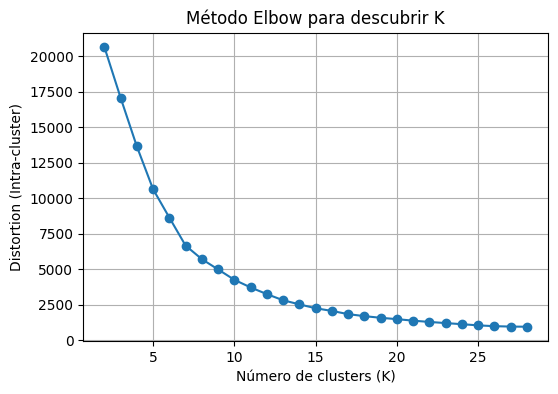

In [19]:
distortions = descubrirK(X_train, k_max=28)


In [20]:
K_OPTIMO = 28

kmeans = KMeans(
    n_clusters=K_OPTIMO,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",28
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [21]:
train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)


In [22]:
import numpy as np

y_train_np = np.asarray(y_train)

train_clusters = kmeans.predict(X_train)
test_clusters = kmeans.predict(X_test)

y_pred = []

for cluster in test_clusters:
    indices = np.where(train_clusters == cluster)[0]

    if len(indices) == 0:
        # fallback seguro
        y_pred.append(np.random.choice(y_train_np))
    else:
        valores, conteos = np.unique(y_train_np[indices], return_counts=True)
        y_pred.append(valores[np.argmax(conteos)])

y_pred = np.array(y_pred)


In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Clustering Results (KMeans)")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")



Clustering Results (KMeans)
Accuracy : 0.9829
Precision: 0.9856
Recall   : 0.9829
F1-score : 0.9827


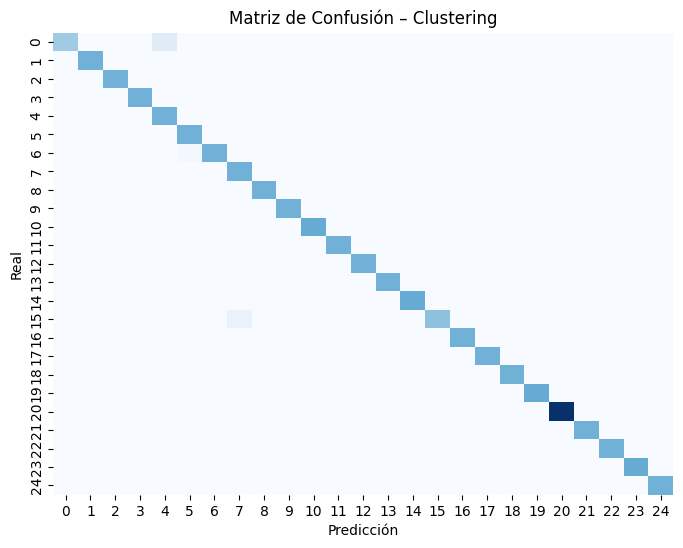

In [24]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap="Blues", cbar=False)
plt.title("Matriz de Confusión – Clustering")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
